In [22]:
# Load in relevant libraries, and alias where appropriate
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# Define relevant variables for the ML task
batch_size = 64
num_classes = 10
learning_rate = 0.001
num_epochs = 10

# Device will determine whether to run the training on GPU or CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [23]:
#Loading the dataset and preprocessing
train_dataset = torchvision.datasets.MNIST(root = './data',
                                               train = True,
                                               transform = transforms.Compose([
                                                      transforms.Resize((32,32)),
                                                      transforms.ToTensor(),
                                                      transforms.Normalize(mean = (0.1307,), std = (0.3081,))]),
                                               download = True)


test_dataset = torchvision.datasets.MNIST(root = './data',
                                              train = False,
                                              transform = transforms.Compose([
                                                      transforms.Resize((32,32)),
                                                      transforms.ToTensor(),
                                                      transforms.Normalize(mean = (0.1325,), std = (0.3105,))]),
                                              download=True)


train_loader = torch.utils.data.DataLoader(dataset = train_dataset,
                                               batch_size = batch_size,
                                               shuffle = True)


test_loader = torch.utils.data.DataLoader(dataset = test_dataset,
                                               batch_size = batch_size,
                                               shuffle = True)

In [24]:
#Defining the convolutional neural network
class LeNet5(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.layer1 = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0),
        nn.BatchNorm2d(6),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer2 = nn.Sequential(
        nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.fc = nn.Linear(400, 120)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(120, 84)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.relu(out)
        out = self.fc1(out)
        out = self.relu1(out)
        out = self.fc2(out)
        return out

In [25]:
model = LeNet5(num_classes).to(device)

#Setting the loss function
cost = nn.CrossEntropyLoss()

#Setting the optimizer with the model parameters and learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

#this is defined to print how many steps are remaining when training
total_step = len(train_loader)

# Part 1. Model Training and Evaluation

## Task I: Train and Evaluate Your Model

In [26]:
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        #Forward pass
        outputs = model(images)
        loss = cost(outputs, labels)
        #Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (i+1) % 400 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, i+1, total_step, loss.item()))

Epoch [1/10], Step [400/938], Loss: 0.1888
Epoch [1/10], Step [800/938], Loss: 0.0793
Epoch [2/10], Step [400/938], Loss: 0.0109
Epoch [2/10], Step [800/938], Loss: 0.0329
Epoch [3/10], Step [400/938], Loss: 0.0075
Epoch [3/10], Step [800/938], Loss: 0.0488
Epoch [4/10], Step [400/938], Loss: 0.0020
Epoch [4/10], Step [800/938], Loss: 0.0121
Epoch [5/10], Step [400/938], Loss: 0.0338
Epoch [5/10], Step [800/938], Loss: 0.0171
Epoch [6/10], Step [400/938], Loss: 0.0033
Epoch [6/10], Step [800/938], Loss: 0.0016
Epoch [7/10], Step [400/938], Loss: 0.0230
Epoch [7/10], Step [800/938], Loss: 0.0071
Epoch [8/10], Step [400/938], Loss: 0.0255
Epoch [8/10], Step [800/938], Loss: 0.0293
Epoch [9/10], Step [400/938], Loss: 0.0028
Epoch [9/10], Step [800/938], Loss: 0.0011
Epoch [10/10], Step [400/938], Loss: 0.0453
Epoch [10/10], Step [800/938], Loss: 0.1269


In [27]:
# Test the model
# In the test phase, we don't need to compute gradients (for memory efficiency)

model.eval()  # Set the model to evaluation mode

with torch.no_grad():
    correct = 0
    total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the 10000 test images: {accuracy:.2f} %')

Accuracy of the network on the 10000 test images: 99.17 %


After training for 10 epochs on the MNIST dataset while utilizing ADAM optimizer, testing results in a 99% accuracy.

## Task II: Analyze the Impact of Training Techniques
1. Data augmentation (Rotation): Train your model with and without random rotations.
2. Data augmentation (Horizontal flip): Train your model with and without random
horizontal flips. (Consider what a horizontal flip does to the semantic meaning of
asymmetrical digits!)
3. Optimization (SGD vs. Adam): Train your model with SGD and then with Adam.
4. Hyper-parameters (Batch-size): Train your model with two different batch sizes.
5. Hyper-parameters (Learning rate): Train your model with two different learning rate

### 1. Random Rotation

In [28]:
# 1. Rotation applied to training set
rotation_degrees = 15

rotated_dataset = torchvision.datasets.MNIST(root = './data',
                                               train = True,
                                               transform = transforms.Compose([
                                                      transforms.Resize((32,32)),
                                                      transforms.RandomRotation(rotation_degrees),
                                                      transforms.ToTensor(),
                                                      transforms.Normalize(mean = (0.1307,), std = (0.3081,))]),
                                               download = True)

rotated_loader = torch.utils.data.DataLoader(dataset = rotated_dataset,
                                               batch_size = batch_size,
                                               shuffle = True)

In [29]:
total_step = len(rotated_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(rotated_loader):
        images = images.to(device)
        labels = labels.to(device)

        #Forward pass
        outputs = model(images)
        loss = cost(outputs, labels)
        #Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (i+1) % 400 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, i+1, total_step, loss.item()))

Epoch [1/10], Step [400/938], Loss: 0.0111
Epoch [1/10], Step [800/938], Loss: 0.0228
Epoch [2/10], Step [400/938], Loss: 0.0076
Epoch [2/10], Step [800/938], Loss: 0.0714
Epoch [3/10], Step [400/938], Loss: 0.0011
Epoch [3/10], Step [800/938], Loss: 0.0157
Epoch [4/10], Step [400/938], Loss: 0.0073
Epoch [4/10], Step [800/938], Loss: 0.0306
Epoch [5/10], Step [400/938], Loss: 0.0021
Epoch [5/10], Step [800/938], Loss: 0.0050
Epoch [6/10], Step [400/938], Loss: 0.0428
Epoch [6/10], Step [800/938], Loss: 0.0331
Epoch [7/10], Step [400/938], Loss: 0.0017
Epoch [7/10], Step [800/938], Loss: 0.0012
Epoch [8/10], Step [400/938], Loss: 0.0480
Epoch [8/10], Step [800/938], Loss: 0.0006
Epoch [9/10], Step [400/938], Loss: 0.0011
Epoch [9/10], Step [800/938], Loss: 0.0476
Epoch [10/10], Step [400/938], Loss: 0.0040
Epoch [10/10], Step [800/938], Loss: 0.0028


In [30]:
model.eval()

with torch.no_grad():
    correct = 0
    total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the 10000 test images: {accuracy:.2f} %')

Accuracy of the network on the 10000 test images: 99.16 %


Random rotations allow the model to generalize better, making the model more robust to inference on unseen data. It is hard to see an improvement on the accuracy of predicting the test set since the original accuracy was already above 99%, but we do see a lower training loss by the end of the trianing epochs.

### 2. Random Horizontal Flip

In [31]:
# 1. Rotation applied to training set
flipped_dataset = torchvision.datasets.MNIST(root = './data',
                                               train = True,
                                               transform = transforms.Compose([
                                                      transforms.Resize((32,32)),
                                                      transforms.RandomHorizontalFlip(p=0.5), # 50% chance to randomly flip data
                                                      transforms.ToTensor(),
                                                      transforms.Normalize(mean = (0.1307,), std = (0.3081,))]),
                                               download = True)

flipped_loader = torch.utils.data.DataLoader(dataset = flipped_dataset,
                                               batch_size = batch_size,
                                               shuffle = True)

In [41]:
total_step = len(flipped_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(flipped_loader):
        images = images.to(device)
        labels = labels.to(device)

        #Forward pass
        outputs = model(images)
        loss = cost(outputs, labels)
        #Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (i+1) % 400 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, i+1, total_step, loss.item()))

Epoch [1/10], Step [400/938], Loss: 0.0012
Epoch [1/10], Step [800/938], Loss: 0.0007
Epoch [2/10], Step [400/938], Loss: 0.0013
Epoch [2/10], Step [800/938], Loss: 0.0003
Epoch [3/10], Step [400/938], Loss: 0.0002
Epoch [3/10], Step [800/938], Loss: 0.0011
Epoch [4/10], Step [400/938], Loss: 0.0008
Epoch [4/10], Step [800/938], Loss: 0.0697
Epoch [5/10], Step [400/938], Loss: 0.0020
Epoch [5/10], Step [800/938], Loss: 0.0005
Epoch [6/10], Step [400/938], Loss: 0.0014
Epoch [6/10], Step [800/938], Loss: 0.0048
Epoch [7/10], Step [400/938], Loss: 0.0004
Epoch [7/10], Step [800/938], Loss: 0.0086
Epoch [8/10], Step [400/938], Loss: 0.0495
Epoch [8/10], Step [800/938], Loss: 0.0027
Epoch [9/10], Step [400/938], Loss: 0.0003
Epoch [9/10], Step [800/938], Loss: 0.0267
Epoch [10/10], Step [400/938], Loss: 0.0001
Epoch [10/10], Step [800/938], Loss: 0.0003


In [42]:
model.eval()

with torch.no_grad():
    correct = 0
    total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the 10000 test images: {accuracy:.2f} %')

Accuracy of the network on the 10000 test images: 98.98 %


Random horizontal flips cause the model to perform slightly worse than previous methods. This could be due to overfitting, but when I tested the model with fewer epochs, the testing accuracy remained in the 98% range. Overall, I think this is because the model trains itself on identifying numbers incorrectly due to how symmetry matters to numbers. If you flip a 3 horizontally and tell the model that a backwards 3 is a normal 3, it will not understand the features and patterns that make a 3 truly into a 3. You CANNOT use horizontal flipping on datasets where orientation is an important feature of the data itself. At that point, you are just altering the and skewing the MNISt dataset without any purpose or reasoning.

### 3. Using Stochastic Gradient Descent (instead of Adam Optimizer)

In [44]:
# switch optimizer to SGD
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [47]:
# retrain using regular dataset

total_step = len(train_loader)
for epoch in range(5):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        #Forward pass
        outputs = model(images)
        loss = cost(outputs, labels)
        #Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (i+1) % 400 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, i+1, total_step, loss.item()))

Epoch [1/10], Step [400/938], Loss: 0.0089
Epoch [1/10], Step [800/938], Loss: 0.0012
Epoch [2/10], Step [400/938], Loss: 0.0001
Epoch [2/10], Step [800/938], Loss: 0.0002
Epoch [3/10], Step [400/938], Loss: 0.0001
Epoch [3/10], Step [800/938], Loss: 0.0005
Epoch [4/10], Step [400/938], Loss: 0.0000
Epoch [4/10], Step [800/938], Loss: 0.0002
Epoch [5/10], Step [400/938], Loss: 0.0023
Epoch [5/10], Step [800/938], Loss: 0.0020


In [48]:
# Test the model
# In the test phase, we don't need to compute gradients (for memory efficiency)

model.eval()  # Set the model to evaluation mode

with torch.no_grad():
    correct = 0
    total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the 10000 test images: {accuracy:.2f} %')

Accuracy of the network on the 10000 test images: 99.08 %


With SGD instead of Adam Optimizer, I got an unexpected result. The model convertged to near 0 on the training data faster than Adam, which I really did not expect. I lowered the training epochs to 5 in order to prevent overfitting during training, then I ran the test. It came in at 99%, similar to Adam Optimizer but converging faster during training. This may be because SGD is better at generalizing data instead of falling into a sharp minima due to a lack of momentum and adaptive learning rate. It's also less prone to overfitting with the right hyperparameter constraints. I would choose SGD going forward with this model.

### 4. Batch-Size of 128 instead of 64

In [50]:
# reverting optimizer back to Adam to compare model accuracy between first test and this test
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [53]:
# retrain using regular dataset and new batch size
batch_size128_loader = torch.utils.data.DataLoader(dataset = train_dataset,
                                               batch_size = 128,
                                               shuffle = True)

total_step = len(batch_size128_loader)
for epoch in range(5):
    for i, (images, labels) in enumerate(batch_size128_loader):
        images = images.to(device)
        labels = labels.to(device)

        #Forward pass
        outputs = model(images)
        loss = cost(outputs, labels)
        #Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (i+1) % 400 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, i+1, total_step, loss.item()))

Epoch [1/10], Step [400/469], Loss: 0.0001
Epoch [2/10], Step [400/469], Loss: 0.0001
Epoch [3/10], Step [400/469], Loss: 0.0013
Epoch [4/10], Step [400/469], Loss: 0.0000
Epoch [5/10], Step [400/469], Loss: 0.0000


In [54]:
# Test the model
# In the test phase, we don't need to compute gradients (for memory efficiency)

model.eval()  # Set the model to evaluation mode

with torch.no_grad():
    correct = 0
    total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the 10000 test images: {accuracy:.2f} %')

Accuracy of the network on the 10000 test images: 99.31 %


A larger batch size result in faster training as expected, resulting in taking 2-5 epochs to reach test loss of 0.000. Test accuracy remained intact as well, reaching 99.31% on the most recent run, which was better than the original run by almost 0.2%. Overall, a combination of optim.SGD and batch_size=128 look the best for this model.

### 5. Learning Rate 0.01

In [56]:
# Retrain model with different learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [58]:
# retrain using regular dataset and new batch size

total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        #Forward pass
        outputs = model(images)
        loss = cost(outputs, labels)
        #Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (i+1) % 400 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, i+1, total_step, loss.item()))

Epoch [1/10], Step [400/938], Loss: 0.0329
Epoch [1/10], Step [800/938], Loss: 0.0125
Epoch [2/10], Step [400/938], Loss: 0.1214
Epoch [2/10], Step [800/938], Loss: 0.0003
Epoch [3/10], Step [400/938], Loss: 0.1790
Epoch [3/10], Step [800/938], Loss: 0.0202
Epoch [4/10], Step [400/938], Loss: 0.0097
Epoch [4/10], Step [800/938], Loss: 0.0359
Epoch [5/10], Step [400/938], Loss: 0.0316
Epoch [5/10], Step [800/938], Loss: 0.0158
Epoch [6/10], Step [400/938], Loss: 0.0056
Epoch [6/10], Step [800/938], Loss: 0.0122
Epoch [7/10], Step [400/938], Loss: 0.0098
Epoch [7/10], Step [800/938], Loss: 0.2346
Epoch [8/10], Step [400/938], Loss: 0.0249
Epoch [8/10], Step [800/938], Loss: 0.0006
Epoch [9/10], Step [400/938], Loss: 0.2874
Epoch [9/10], Step [800/938], Loss: 0.0244
Epoch [10/10], Step [400/938], Loss: 0.0117
Epoch [10/10], Step [800/938], Loss: 0.0021


In [59]:
# Test the model
# In the test phase, we don't need to compute gradients (for memory efficiency)

model.eval()  # Set the model to evaluation mode

with torch.no_grad():
    correct = 0
    total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the 10000 test images: {accuracy:.2f} %')

Accuracy of the network on the 10000 test images: 97.82 %


Increasing the learning rate to 0.01 from 0.001 expectedly worsened the performance of the model on the test cases. 0.01 generally isn't a good learning rate because it causes the model to miss minima during gradient descent, skipping over "holes" in the gradient that would decrease the loss during training and testing. With a higher learning rate, the model "flattens" out its gradient by skipping over the fine grain valleys during descent.



---


# Part 2: Adversarial Examples

In [129]:
#Loading the dataset and preprocessing
train_dataset = torchvision.datasets.MNIST(root = './data',
                                               train = True,
                                               transform = transforms.Compose([
                                                      transforms.Resize((32,32)),
                                                      transforms.ToTensor(),
                                                      transforms.Normalize(mean = (0.1307,), std = (0.3081,))]),
                                               download = True)


test_dataset = torchvision.datasets.MNIST(root = './data',
                                              train = False,
                                              transform = transforms.Compose([
                                                      transforms.Resize((32,32)),
                                                      transforms.ToTensor(),
                                                      transforms.Normalize(mean = (0.1325,), std = (0.3105,))]),
                                              download=True)


train_loader = torch.utils.data.DataLoader(dataset = train_dataset,
                                               batch_size = batch_size,
                                               shuffle = True)


test_loader = torch.utils.data.DataLoader(dataset = test_dataset,
                                               batch_size = batch_size,
                                               shuffle = True)

In [130]:
# new model using SGD and batch_size = 128

batch_size = 128
num_classes = 10
learning_rate = 0.001
num_epochs = 10

#Setting the optimizer with the model parameters and learning rate
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
model = LeNet5(num_classes).to(device)

#this is defined to print how many steps are remaining when training
total_step = len(train_loader)

In [131]:
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        #Forward pass
        outputs = model(images)
        loss = cost(outputs, labels)
        #Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (i+1) % 400 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, i+1, total_step, loss.item()))

model.eval()

Epoch [1/10], Step [400/469], Loss: 2.3095
Epoch [2/10], Step [400/469], Loss: 2.3295
Epoch [3/10], Step [400/469], Loss: 2.3150
Epoch [4/10], Step [400/469], Loss: 2.3201
Epoch [5/10], Step [400/469], Loss: 2.3128
Epoch [6/10], Step [400/469], Loss: 2.3182
Epoch [7/10], Step [400/469], Loss: 2.3121
Epoch [8/10], Step [400/469], Loss: 2.3238
Epoch [9/10], Step [400/469], Loss: 2.3078
Epoch [10/10], Step [400/469], Loss: 2.3182


LeNet5(
  (layer1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=400, out_features=120, bias=True)
  (relu): ReLU()
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)

### Task III: Attack Your Models

In [132]:
def PGD(x, y, model, loss_fn, niter, epsilon, stepsize, randinit=True):
    # Ensure x has gradients enabled from the start
    x_adv = x.clone().detach().to(device)

    if randinit:
        # Start at a random point within the epsilon ball
        delta = torch.zeros_like(x_adv).uniform_(-epsilon, epsilon)
        x_adv = torch.clamp(x_adv + delta, 0, 1)

    for i in range(niter):
        # This tells PyTorch to track operations on x_adv for this specific iteration
        x_adv.requires_grad = True

        outputs = model(x_adv)
        loss = loss_fn(outputs, y)

        model.zero_grad()
        loss.backward()

        # We use grad.data to avoid tracking the update itself in the graph
        if x_adv.grad is not None:
            grad_sign = x_adv.grad.data.sign()

            with torch.no_grad():
                x_adv = x_adv + stepsize * grad_sign
                # L-infinity projection
                delta = torch.clamp(x_adv - x, min=-epsilon, max=epsilon)
                x_adv = torch.clamp(x + delta, 0, 1)
        else:
            print("Warning: Gradient is None. Check if model is in eval mode or loss is valid.")
            break

    return x_adv.detach()

### Task IV: Analyze Attack Factors

Subtask IV-1: Attack Hyper-Parameters

In [133]:
def evaluate_attack(model, loader, niter, epsilon, stepsize):
    model.eval()
    correct = 0
    total = 0
    loss_fn = nn.CrossEntropyLoss()

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        adv_images = PGD(images, labels, model, loss_fn, niter, epsilon, stepsize)

        outputs = model(adv_images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return 100 * correct / total

# --- Task IV-1.1: Varying Iterations ---
print("Running Subtask IV-1.1...")
iters_to_test = [1, 2, 3, 4, 5, 10, 20, 30, 40, 80, 100]
acc_vs_iters = []
for ni in iters_to_test:
    acc = evaluate_attack(model, test_loader, ni, 0.3, 2/255)
    acc_vs_iters.append(acc)
    print(f"Iterations: {ni} | Accuracy: {acc:.2f}%")

# --- Task IV-1.2: Varying Epsilon ---
print("\nRunning Subtask IV-1.2...")
eps_to_test = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0]
acc_vs_eps = []
for eps in eps_to_test:
    acc = evaluate_attack(model, test_loader, 5, eps, 2/255)
    acc_vs_eps.append(acc)
    print(f"Epsilon: {eps} | Accuracy: {acc:.2f}%")

Running Subtask IV-1.1...
Iterations: 1 | Accuracy: 8.49%
Iterations: 2 | Accuracy: 7.70%
Iterations: 3 | Accuracy: 7.04%
Iterations: 4 | Accuracy: 6.17%
Iterations: 5 | Accuracy: 5.63%
Iterations: 10 | Accuracy: 3.35%
Iterations: 20 | Accuracy: 1.18%
Iterations: 30 | Accuracy: 0.54%
Iterations: 40 | Accuracy: 0.28%
Iterations: 80 | Accuracy: 0.13%
Iterations: 100 | Accuracy: 0.11%

Running Subtask IV-1.2...
Epsilon: 0.01 | Accuracy: 8.62%
Epsilon: 0.02 | Accuracy: 7.87%
Epsilon: 0.03 | Accuracy: 7.37%
Epsilon: 0.04 | Accuracy: 7.10%
Epsilon: 0.05 | Accuracy: 7.02%
Epsilon: 0.1 | Accuracy: 6.47%
Epsilon: 0.2 | Accuracy: 6.17%
Epsilon: 0.3 | Accuracy: 5.70%
Epsilon: 0.4 | Accuracy: 5.30%
Epsilon: 0.5 | Accuracy: 1.14%
Epsilon: 1.0 | Accuracy: 0.40%


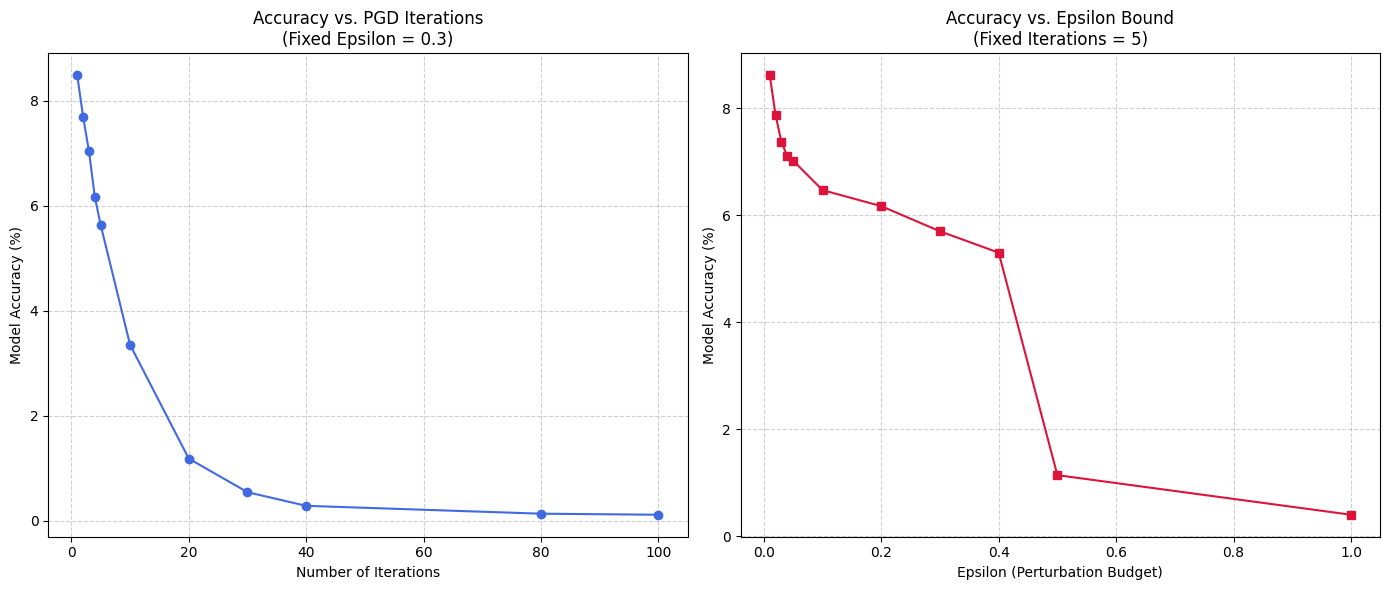

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot 1: Iterations
plt.subplot(1, 2, 1)
plt.plot(iters_to_test, acc_vs_iters, marker='o', color='royalblue')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title("Accuracy vs. PGD Iterations\n(Fixed Epsilon = 0.3)")
plt.xlabel("Number of Iterations")
plt.ylabel("Model Accuracy (%)")

# Plot 2: Epsilon
plt.subplot(1, 2, 2)
plt.plot(eps_to_test, acc_vs_eps, marker='s', color='crimson')
plt.grid(True, linestyle='--', alpha=0.6)
plt.title("Accuracy vs. Epsilon Bound\n(Fixed Iterations = 5)")
plt.xlabel("Epsilon (Perturbation Budget)")
plt.ylabel("Model Accuracy (%)")

plt.tight_layout()
plt.show()

The blue plot illustrates the impact of search depth on attack effectiveness. As the number of iterations increases, the model's accuracy rapidly decays because PGD is an iterative optimization process. A single-step attack might only find a mildly confusing perturbation, but by taking multiple smaller steps, the adversary can "navigate" the complex, non-linear loss landscape of the neural network to find a much more damaging direction. The curve eventually plateaus because once the adversary has pushed the sample to a local maximum within the allowed budget, further iterations simply keep the image at that boundary without significantly increasing the loss.The red plot demonstrates the impact of the perturbation budget, or Epsilon. Epsilon defines the maximum distance a pixel can be moved from its original value. At very low values, the perturbations are nearly invisible and the model's learned features remain robust enough to classify the digit correctly. However, as Epsilon grows, the attacker gains more "power" to overwrite the original image's characteristics. On the MNIST dataset, an Epsilon of $0.5$ or higher allows the attacker to essentially replace the digit's defining edges with high-contrast noise, leading to the sharp "cliff" in accuracy where the model can no longer extract any meaningful features from the original sample.

Subtask IV-2: Training Techniques and Regularization

In [136]:
class LeNetWithDropout(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(LeNetWithDropout, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*4*4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.dropout = nn.Dropout(p=dropout_rate) # The new Dropout layer
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.relu(torch.max_pool2d(self.conv1(x), 2))
        x = torch.relu(torch.max_pool2d(self.conv2(x), 2))
        x = x.view(-1, 16*4*4)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.dropout(x) # Applied before penultimate layer
        x = self.fc3(x)
        return x

In [137]:
weight_decays = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
results = []

for wd in weight_decays:
    print(f"Training model with weight decay: {wd}")
    model = LeNet5(num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=wd)

    # --- INSERT YOUR TRAINING LOOP HERE ---
    total_step = len(train_loader)
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            #Forward pass
            outputs = model(images)
            loss = cost(outputs, labels)
            #Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if (i+1) % len(train_loader) == 0:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, i+1, total_step, loss.item()))

    # Evaluate
    clean_acc = evaluate_attack(model, test_loader, niter=0, epsilon=0, stepsize=0)
    robust_acc = evaluate_attack(model, test_loader, niter=5, epsilon=0.3, stepsize=2/255)

    results.append({
        'wd': wd,
        'clean': clean_acc,
        'robust': robust_acc,
        'degradation': clean_acc - robust_acc
    })

Training model with weight decay: 1e-05
Epoch [1/10], Step [469/469], Loss: 0.0221
Epoch [2/10], Step [469/469], Loss: 0.0399
Epoch [3/10], Step [469/469], Loss: 0.0092
Epoch [4/10], Step [469/469], Loss: 0.0608
Epoch [5/10], Step [469/469], Loss: 0.0259
Epoch [6/10], Step [469/469], Loss: 0.0009
Epoch [7/10], Step [469/469], Loss: 0.0141
Epoch [8/10], Step [469/469], Loss: 0.0014
Epoch [9/10], Step [469/469], Loss: 0.0305
Epoch [10/10], Step [469/469], Loss: 0.0153
Training model with weight decay: 0.0001
Epoch [1/10], Step [469/469], Loss: 0.0268
Epoch [2/10], Step [469/469], Loss: 0.0444
Epoch [3/10], Step [469/469], Loss: 0.0774
Epoch [4/10], Step [469/469], Loss: 0.0059
Epoch [5/10], Step [469/469], Loss: 0.0281
Epoch [6/10], Step [469/469], Loss: 0.0053
Epoch [7/10], Step [469/469], Loss: 0.0236
Epoch [8/10], Step [469/469], Loss: 0.0062
Epoch [9/10], Step [469/469], Loss: 0.0045
Epoch [10/10], Step [469/469], Loss: 0.0410
Training model with weight decay: 0.001
Epoch [1/10], Ste

The training logs reveal a clear trade-off between model flexibility and the constraints imposed by $L_2$ regularization. At low weight decay values, such as 1e-05 and 0.0001, the model achieves very low training loss, suggesting it has developed complex, sharp decision boundaries that prioritize high accuracy on clean data. However, these models are typically the most vulnerable to adversarial degradation; because the weights are not strictly constrained, the loss landscape remains "jagged," allowing a PGD attack to easily find small perturbations that trigger massive shifts in the model’s output. In these cases, you will likely see a wide gap between near-perfect clean accuracy and a total collapse in robust accuracy.As weight decay increases to 0.001, we observe what is often the "sweet spot" for natural robustness. The regularization penalty forces the model to rely on more distributed features rather than individual, high-weight pixels, effectively smoothing the loss landscape. This smoothing makes the gradient-based search of the PGD attack less efficient, typically resulting in a smaller accuracy degradation gap compared to the under-regularized models. While the model remains vulnerable to strong attacks, this moderate decay provides a baseline level of stability that prevents the adversary from flipping the classification as easily as it would against an overfitted model.At the highest extreme of 0.1, the weight decay becomes counterproductive. The significantly higher training loss indicates that the model is underfitting, as the heavy penalty prevents it from learning the complex geometric features necessary to distinguish between MNIST digits. While the statistical "degradation" (the gap between clean and adversarial accuracy) might appear smaller here, it is a misleading metric of robustness; the model's base utility is already compromised. Ultimately, these results demonstrate that while weight decay can marginally improve a model's "smoothness," it acts more as a buffer against overfitting than a true defense against determined white-box adversaries.